# Cell 1 Check gpu

In [1]:
import sys, torch

print(sys.executable)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


d:\Documents\Fuzzy_Integral\fetal_brain_ultrasound_fi_ensemble_16cls\.venv\Scripts\python.exe
torch: 2.7.1+cu118
cuda: True
gpu: NVIDIA GeForce RTX 3050 Laptop GPU


# Cell 2 Load dataset

In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path(r"D:\Documents\Fuzzy_Integral\fetal_brain_ultrasound_fi_ensemble_16cls\data\Fetal Brain Abnormalities Ultrasound.v1i.multiclass")
splits = {s: ROOT/s for s in ["train","valid","test"]}
dfs = {s: pd.read_csv(p/"_classes.csv") for s,p in splits.items()}

classes = [c for c in dfs["train"].columns if c != "filename"]
print("n_classes:", len(classes))
print("classes:", classes)
for s,df in dfs.items():
    print(s, "rows:", len(df), "imgs_dir_ok:", (splits[s]).exists())


n_classes: 16
classes: [' anold-chiari-malformation', ' arachnoid-cyst', ' cerebellah-hypoplasia', ' colphocephaly', ' encephalocele', ' holoprosencephaly', ' hydracenphaly', ' intracranial-hemorrdge', ' intracranial-tumor', ' m-magna', ' mild-ventriculomegaly', ' moderate-ventriculomegaly', ' normal', ' polencephaly', ' severe-ventriculomegaly', ' vein-of-galen']
train rows: 1418 imgs_dir_ok: True
valid rows: 174 imgs_dir_ok: True
test rows: 176 imgs_dir_ok: True


In [3]:
from PIL import Image

for s,df in dfs.items():
    paths = (splits[s] / df["filename"]).tolist()
    missing = sum([not p.exists() for p in paths])
    print(s, "missing:", missing, "example:", str(paths[0]))


train missing: 0 example: D:\Documents\Fuzzy_Integral\fetal_brain_ultrasound_fi_ensemble_16cls\data\Fetal Brain Abnormalities Ultrasound.v1i.multiclass\train\Copy-of-arachnoid-cyst-37b_aug_0_png_jpg.rf.3e46b256d159cc7a64cf2e1c720b5b17.jpg
valid missing: 0 example: D:\Documents\Fuzzy_Integral\fetal_brain_ultrasound_fi_ensemble_16cls\data\Fetal Brain Abnormalities Ultrasound.v1i.multiclass\valid\Copy-of-mild-ventriculomegaly-19a_aug_0_png_jpg.rf.e4e908aac0bd913aefd81b34b93899a5.jpg
test missing: 0 example: D:\Documents\Fuzzy_Integral\fetal_brain_ultrasound_fi_ensemble_16cls\data\Fetal Brain Abnormalities Ultrasound.v1i.multiclass\test\Copy-of-mild-ventriculomegaly-18c_aug_2_png_jpg.rf.1a7978b80bec239d05c1870f509b7aaa.jpg


# Cell 3 EDA

In [4]:
import numpy as np

classes = [c.strip() for c in classes]
for s in dfs:
    dfs[s].columns = ["filename"] + classes

counts = {s: dfs[s][classes].sum().astype(int) for s in dfs}
dist = pd.DataFrame(counts).T
print(dist.sum(axis=1).to_dict())
dist

{'train': 1418, 'valid': 174, 'test': 176}


,anold-chiari-malformation,arachnoid-cyst,cerebellah-hypoplasia,colphocephaly,encephalocele,holoprosencephaly,hydracenphaly,intracranial-hemorrdge,intracranial-tumor,m-magna,mild-ventriculomegaly,moderate-ventriculomegaly,normal,polencephaly,severe-ventriculomegaly,vein-of-galen
train,44,112,103,72,113,7,17,43,14,32,195,258,227,83,94,4
valid,3,14,11,7,18,1,1,7,0,2,27,30,31,8,13,1
test,3,13,16,11,15,4,2,8,0,4,24,26,24,7,19,0


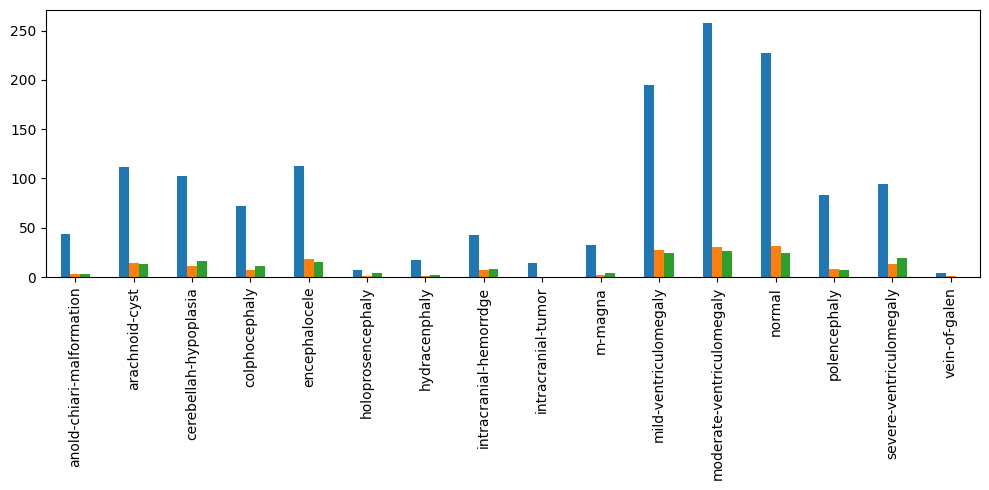

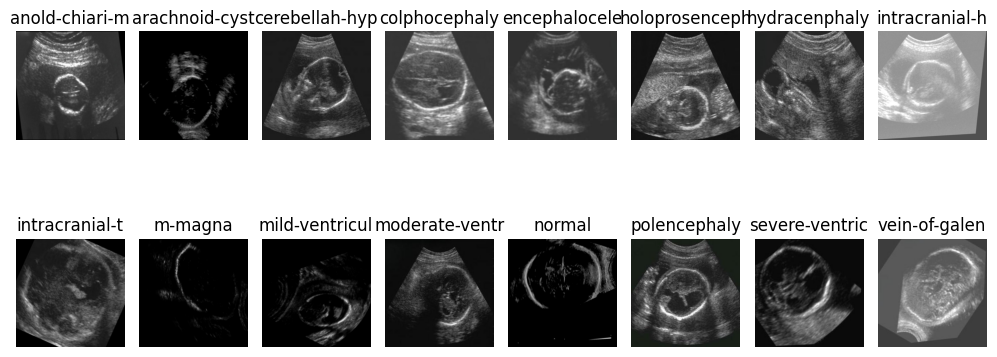

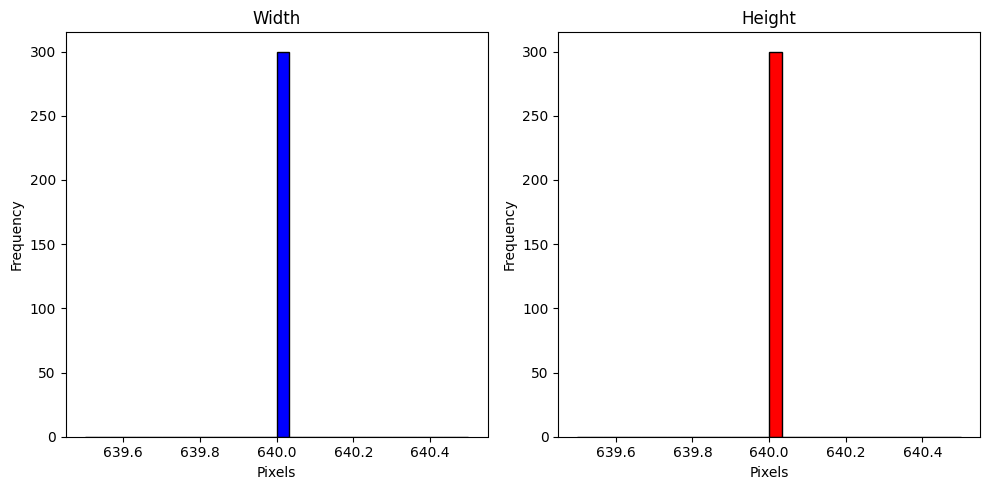

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# (1) label distribution
dist.T.plot(kind="bar", figsize=(10,5), legend=False)
plt.tight_layout(); plt.show()

# (2) 1 image per class (train)
fig, ax = plt.subplots(2, 8, figsize=(10,5))
for i,c in enumerate(classes):
    row = dfs["train"].loc[dfs["train"][c]==1].sample(1, random_state=0).iloc[0]
    img = Image.open(splits["train"]/row["filename"]).convert("RGB")
    ax[i//8, i%8].imshow(img); ax[i//8, i%8].set_title(c[:14]); ax[i//8, i%8].axis("off")
plt.tight_layout(); plt.show()

# (3) size histogram (train)
ws, hs = [], []
for fn in dfs["train"]["filename"].sample(300, random_state=0):
    w, h = Image.open(splits["train"] / fn).size
    ws.append(w)
    hs.append(h)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(ws, bins=30, color='blue', edgecolor='black')
ax1.set_title("Width")
ax1.set_xlabel("Pixels")
ax1.set_ylabel("Frequency")

ax2.hist(hs, bins=30, color='red', edgecolor='black')
ax2.set_title("Height")
ax2.set_xlabel("Pixels")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Cell 4 Seed + Device (CUDA)

In [6]:
import os, random, numpy as np, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Cell 5 Dataset (CSV one-hot) + Transforms + Dataloader (224/299)

In [7]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from torchvision import transforms 

IMNET_MEAN = (0.485, 0.456, 0.406)
IMNET_STD  = (0.229, 0.224, 0.225)

class RFDataset(Dataset):
    def __init__(self, df, img_dir, classes, tfm):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.classes = classes
        self.y = self.df[classes].to_numpy().argmax(1).astype(int)
        self.tfm = tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        fn = self.df.loc[i, "filename"]
        x = Image.open(self.img_dir/fn).convert("RGB")
        x = self.tfm(x)
        y = int(self.y[i])
        return x, y

def make_loaders(img_size, batch_size, use_sampler=True, num_workers=0):
    train_tfm = transforms.Compose([
        transforms.Resize(int(img_size*1.15)),
        transforms.RandomResizedCrop(img_size, scale=(0.85, 1.0)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(IMNET_MEAN, IMNET_STD),
    ])
    eval_tfm = transforms.Compose([
        transforms.Resize(int(img_size*1.15)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMNET_MEAN, IMNET_STD),
    ])
    tr = RFDataset(dfs["train"], splits["train"], classes, train_tfm)
    va = RFDataset(dfs["valid"], splits["valid"], classes, eval_tfm)
    te = RFDataset(dfs["test"],  splits["test"],  classes, eval_tfm)

    sampler = None
    if use_sampler:
        c = np.bincount(tr.y, minlength=len(classes))
        w = 1.0 / np.maximum(c, 1)
        sampler = WeightedRandomSampler(w[tr.y], num_samples=len(tr.y), replacement=True)

    tr_loader = DataLoader(tr, batch_size=batch_size, shuffle=(sampler is None), sampler=sampler,
                           num_workers=num_workers, pin_memory=True, drop_last=True)
    va_loader = DataLoader(va, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    te_loader = DataLoader(te, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return tr_loader, va_loader, te_loader

# Cell 6 Sanity Check Batch (shape + label range)

In [8]:
tr224, va224, te224 = make_loaders(224, batch_size=32, use_sampler=True)
tr299, va299, te299 = make_loaders(299, batch_size=16, use_sampler=True)

x,y = next(iter(tr224)); print("224:", x.shape, y.shape, y.min().item(), y.max().item())
x,y = next(iter(tr299)); print("299:", x.shape, y.shape, y.min().item(), y.max().item())

224: torch.Size([32, 3, 224, 224]) torch.Size([32]) 0 15
299: torch.Size([16, 3, 299, 299]) torch.Size([16]) 1 15


# Cell 7 Hyperparams chung + batch/size theo model

In [9]:
NUM_CLASSES = len(classes)

CFG = {
  "seed": SEED,
  "epochs": 30,
  "patience":5,
  "lr": 3e-4,
  "wd": 1e-4,
  "label_smoothing": 0.05,
  "amp": True,
  "num_workers": 0,
}

MODEL_CFG = {
  "xception":    {"img": 299, "bs": 8,  "accum": 2},
  "resnet50":    {"img": 224, "bs": 16, "accum": 2},
  "densenet121": {"img": 224, "bs": 16, "accum": 2},
  "vgg16":       {"img": 224, "bs": 16, "accum": 2},
}

CFG, MODEL_CFG

({'seed': 42,
  'epochs': 30,
  'patience': 5,
  'lr': 0.0003,
  'wd': 0.0001,
  'label_smoothing': 0.05,
  'amp': True,
  'num_workers': 0},
 {'xception': {'img': 299, 'bs': 8, 'accum': 2},
  'resnet50': {'img': 224, 'bs': 16, 'accum': 2},
  'densenet121': {'img': 224, 'bs': 16, 'accum': 2},
  'vgg16': {'img': 224, 'bs': 16, 'accum': 2}})

# Cell 8 Class imbalance handling

In [10]:
y_tr = dfs["train"][classes].to_numpy().argmax(1)
cnt = np.bincount(y_tr, minlength=len(classes))
w_cls = (cnt.sum() / np.maximum(cnt, 1)).astype(np.float32)
w_cls = torch.tensor(w_cls / w_cls.mean(), device=device)

print("min_count:", int(cnt.min()), "max_count:", int(cnt.max()))
w_cls[:5], w_cls.mean()

min_count: 4 max_count: 258


(tensor([0.5365, 0.2108, 0.2292, 0.3279, 0.2089], device='cuda:0'),
 tensor(1.0000, device='cuda:0'))

In [11]:
USE_MIXUP = True
MIXUP_ALPHA = 0.2
USE_CUTMIX = False

# Cell 9 Loss + Metrics (macro-F1) + Eval

In [15]:
import torch, torch.nn as nn
from torch.amp import autocast, GradScaler
from torchmetrics.classification import MulticlassF1Score

criterion = nn.CrossEntropyLoss(weight=w_cls, label_smoothing=CFG["label_smoothing"])
scaler = GradScaler("cuda", enabled=CFG["amp"])
f1_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(device)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    loss_sum, n, correct = 0.0, 0, 0
    f1_metric.reset()
    for x,y in loader:
        x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with autocast("cuda", enabled=CFG["amp"]):
            logits = model(x)
            loss = criterion(logits, y)
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        n += y.size(0)
        f1_metric.update(pred, y)
    return loss_sum/n, correct/n, float(f1_metric.compute())


# Cell 10 Model Factory (Xception/ResNet50/DenseNet121/VGG16)

In [16]:
import timm
from torchvision import models

def build_model(name):
    name = name.lower()
    if name == "xception":
        m = timm.create_model("xception", pretrained=True, num_classes=NUM_CLASSES)
    elif name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
    elif name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    else:
        raise ValueError(name)
    return m.to(device)

# Cell 11 Train 4 Models (loop) + Save Best (val macro-F1)

In [17]:
import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path

CKPT_DIR = Path("outputs/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR  = Path("outputs/logs"); LOG_DIR.mkdir(parents=True, exist_ok=True)

def fit_one(model_name):
    mc = MODEL_CFG[model_name]
    tr, va, _ = make_loaders(mc["img"], mc["bs"], use_sampler=False, num_workers=CFG["num_workers"])
    model = build_model(model_name)
    opt = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["wd"])
    sch = CosineAnnealingLR(opt, T_max=CFG["epochs"])
    best_f1, bad = -1.0, 0
    hist = []

    for epoch in range(1, CFG["epochs"]+1):
        model.train()
        loss_sum, n, correct = 0.0, 0, 0
        f1_metric.reset()
        opt.zero_grad(set_to_none=True)

        for i,(x,y) in enumerate(tr, 1):
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with autocast("cuda", enabled=CFG["amp"]):
                logits = model(x)
                loss = criterion(logits, y) / mc["accum"]
            scaler.scale(loss).backward()

            if i % mc["accum"] == 0:
                scaler.step(opt); scaler.update()
                opt.zero_grad(set_to_none=True)

            loss_sum += float(loss.item()) * y.size(0) * mc["accum"]
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            n += y.size(0)
            f1_metric.update(pred, y)

        tr_loss, tr_acc, tr_f1 = loss_sum/n, correct/n, float(f1_metric.compute())
        va_loss, va_acc, va_f1 = evaluate(model, va)
        sch.step()

        hist.append([epoch, tr_loss, tr_acc, tr_f1, va_loss, va_acc, va_f1, opt.param_groups[0]["lr"]])

        if va_f1 > best_f1:
            best_f1, bad = va_f1, 0
            torch.save({
                "model_name": model_name,
                "img_size": mc["img"],
                "state_dict": model.state_dict(),
                "classes": classes,
                "class_to_idx": {c:i for i,c in enumerate(classes)},
                "best_val_f1": best_f1,
                "cfg": CFG,
                "model_cfg": mc,
            }, CKPT_DIR/f"{model_name}_best.pt")
        else:
            bad += 1
            if bad >= CFG["patience"]:
                break

    df = pd.DataFrame(hist, columns=["epoch","tr_loss","tr_acc","tr_f1","va_loss","va_acc","va_f1","lr"])
    df.to_csv(LOG_DIR/f"{model_name}.csv", index=False)
    return df, best_f1

all_logs = {}
for name in ["xception","resnet50","densenet121","vgg16"]:
    df, bf1 = fit_one(name)
    all_logs[name] = bf1
all_logs

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Acer/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:10<00:00, 10.2MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Acer/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:56<00:00, 9.80MB/s] 


{'xception': 0.9043788313865662,
 'resnet50': 0.9720635414123535,
 'densenet121': 0.9873015880584717,
 'vgg16': 0.7223862409591675}

# Cell 12 Load Best Checkpoints

In [18]:
import torch
from pathlib import Path

CKPT_DIR = Path("outputs/checkpoints")

def load_best(name):
    ck = torch.load(CKPT_DIR/f"{name}_best.pt", map_location="cpu")
    m = build_model(ck["model_name"])
    m.load_state_dict(ck["state_dict"], strict=True)
    m.eval()
    return m.to(device), ck["img_size"]

best_models = {n: load_best(n) for n in ["xception","resnet50","densenet121","vgg16"]}
{n: best_models[n][1] for n in best_models}

d:\Documents\Fuzzy_Integral\fetal_brain_ultrasound_fi_ensemble_16cls\.venv\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


{'xception': 299, 'resnet50': 224, 'densenet121': 224, 'vgg16': 224}

# Cell 13 Test Metrics + Confusion Matrix + Report (per model)

xception test_acc: 0.9432 test_f1_macro: 0.9523
                           precision    recall  f1-score   support

anold-chiari-malformation     1.0000    1.0000    1.0000         3
           arachnoid-cyst     1.0000    0.9231    0.9600        13
    cerebellah-hypoplasia     0.8000    1.0000    0.8889        16
            colphocephaly     1.0000    0.7273    0.8421        11
            encephalocele     0.8824    1.0000    0.9375        15
        holoprosencephaly     1.0000    1.0000    1.0000         4
            hydracenphaly     1.0000    1.0000    1.0000         2
   intracranial-hemorrdge     1.0000    0.8750    0.9333         8
       intracranial-tumor     0.0000    0.0000    0.0000         0
                  m-magna     1.0000    1.0000    1.0000         4
    mild-ventriculomegaly     0.9600    1.0000    0.9796        24
moderate-ventriculomegaly     0.9130    0.8077    0.8571        26
                   normal     1.0000    1.0000    1.0000        24
             

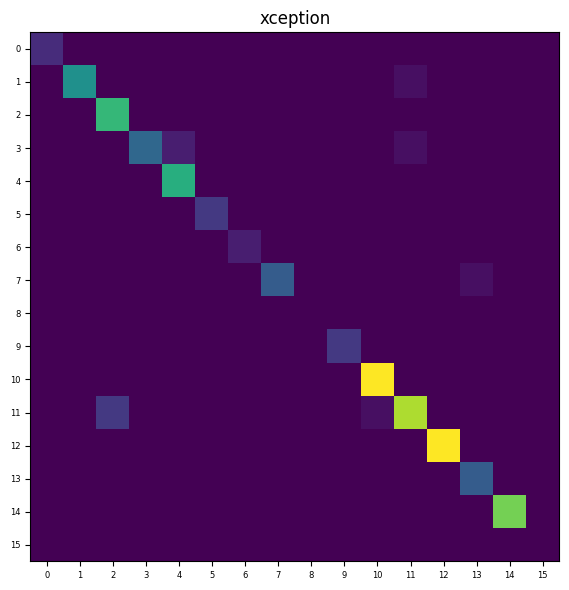

resnet50 test_acc: 0.9602 test_f1_macro: 0.9021
                           precision    recall  f1-score   support

anold-chiari-malformation     1.0000    1.0000    1.0000         3
           arachnoid-cyst     1.0000    1.0000    1.0000        13
    cerebellah-hypoplasia     0.8824    0.9375    0.9091        16
            colphocephaly     1.0000    0.9091    0.9524        11
            encephalocele     1.0000    0.9333    0.9655        15
        holoprosencephaly     1.0000    1.0000    1.0000         4
            hydracenphaly     1.0000    1.0000    1.0000         2
   intracranial-hemorrdge     1.0000    0.8750    0.9333         8
       intracranial-tumor     0.0000    0.0000    0.0000         0
                  m-magna     0.8000    1.0000    0.8889         4
    mild-ventriculomegaly     0.9600    1.0000    0.9796        24
moderate-ventriculomegaly     0.9200    0.8846    0.9020        26
                   normal     1.0000    1.0000    1.0000        24
             

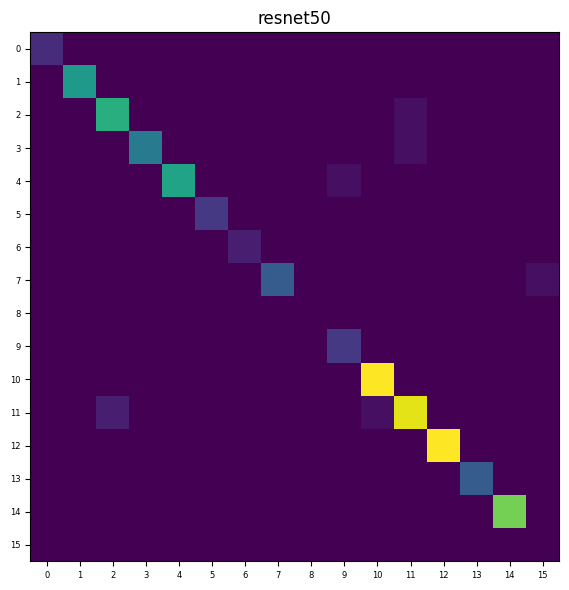

densenet121 test_acc: 0.9375 test_f1_macro: 0.8381
                           precision    recall  f1-score   support

anold-chiari-malformation     1.0000    1.0000    1.0000         3
           arachnoid-cyst     1.0000    1.0000    1.0000        13
    cerebellah-hypoplasia     0.7895    0.9375    0.8571        16
            colphocephaly     1.0000    0.9091    0.9524        11
            encephalocele     1.0000    0.9333    0.9655        15
        holoprosencephaly     1.0000    1.0000    1.0000         4
            hydracenphaly     1.0000    1.0000    1.0000         2
   intracranial-hemorrdge     1.0000    0.8750    0.9333         8
       intracranial-tumor     0.0000    0.0000    0.0000         0
                  m-magna     1.0000    1.0000    1.0000         4
    mild-ventriculomegaly     0.9600    1.0000    0.9796        24
moderate-ventriculomegaly     0.9130    0.8077    0.8571        26
                   normal     1.0000    0.9167    0.9565        24
          

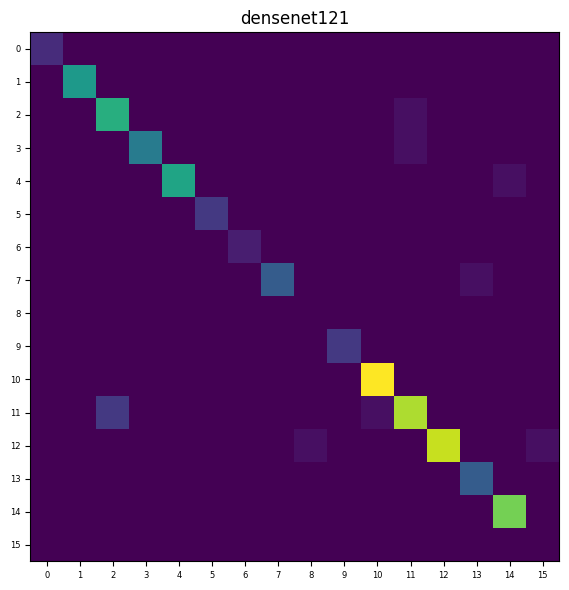

vgg16 test_acc: 0.7216 test_f1_macro: 0.6674
                           precision    recall  f1-score   support

anold-chiari-malformation     0.4000    0.6667    0.5000         3
           arachnoid-cyst     0.7857    0.8462    0.8148        13
    cerebellah-hypoplasia     0.6429    0.5625    0.6000        16
            colphocephaly     0.7000    0.6364    0.6667        11
            encephalocele     0.7778    0.9333    0.8485        15
        holoprosencephaly     0.6667    0.5000    0.5714         4
            hydracenphaly     0.5000    1.0000    0.6667         2
   intracranial-hemorrdge     1.0000    0.6250    0.7692         8
       intracranial-tumor     0.0000    0.0000    0.0000         0
                  m-magna     0.5000    0.7500    0.6000         4
    mild-ventriculomegaly     0.8500    0.7083    0.7727        24
moderate-ventriculomegaly     0.7000    0.5385    0.6087        26
                   normal     0.9130    0.8750    0.8936        24
             pol

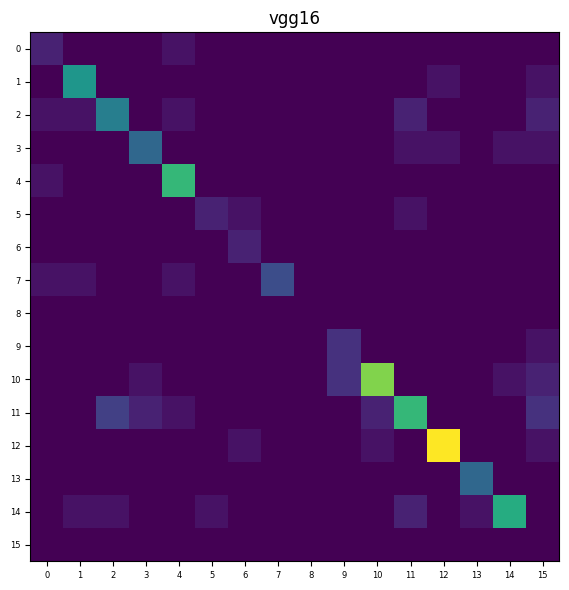

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch

@torch.no_grad()
def predict_all(model, loader):
    ys, ps = [], []
    for x,y in loader:
        x = x.to(device, non_blocking=True)
        with autocast("cuda", enabled=CFG["amp"]):
            logits = model(x)
        ps.append(logits.argmax(1).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def eval_model(name):
    model, img = best_models[name]
    _, _, te = make_loaders(img, MODEL_CFG[name]["bs"], use_sampler=False, num_workers=0)
    y, p = predict_all(model, te)

    acc = (p==y).mean()
    f1 = float(MulticlassF1Score(num_classes=NUM_CLASSES, average="macro")(
        torch.tensor(p), torch.tensor(y)
    ))
    print(name, "test_acc:", round(acc,4), "test_f1_macro:", round(f1,4))
    print(classification_report(
        y, p,
        labels=list(range(NUM_CLASSES)),
        target_names=classes,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y, p, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title(name)
    plt.xticks(range(NUM_CLASSES), range(NUM_CLASSES), fontsize=6)
    plt.yticks(range(NUM_CLASSES), range(NUM_CLASSES), fontsize=6)
    plt.tight_layout(); plt.show()

for n in ["xception","resnet50","densenet121","vgg16"]:
    eval_model(n)


# Cell 14 Save state_dict + config + class mapping for outputs/

In [22]:
from pathlib import Path
import json, torch

OUT = Path("outputs"); OUT.mkdir(exist_ok=True, parents=True)

run = {
  "root": str(ROOT),
  "splits": {k:str(v) for k,v in splits.items()},
  "classes": classes,
  "class_to_idx": {c:i for i,c in enumerate(classes)},
  "cfg": CFG,
  "model_cfg": MODEL_CFG,
  "val_best_f1": {k: float(torch.load(Path("outputs/checkpoints")/f"{k}_best.pt", map_location="cpu")["best_val_f1"])
                  for k in ["xception","resnet50","densenet121","vgg16"]}
}
(Path("outputs")/"run_config.json").write_text(json.dumps(run, indent=2), encoding="utf-8")
run["val_best_f1"]

{'xception': 0.9043788313865662,
 'resnet50': 0.9720635414123535,
 'densenet121': 0.9873015880584717,
 'vgg16': 0.7223862409591675}

# Cell 15 Cache Probs (valid/test) for 4 model

In [23]:
import numpy as np, torch
import torch.nn.functional as F
from torch.amp import autocast

ORDER = ["xception","resnet50","densenet121","vgg16"]

@torch.no_grad()
def probs_split(name, split):
    model, img = best_models[name]
    _, va, te = make_loaders(img, MODEL_CFG[name]["bs"], use_sampler=False, num_workers=0)
    loader = va if split=="valid" else te
    ps, ys = [], []
    for x,y in loader:
        x = x.to(device, non_blocking=True)
        with autocast("cuda", enabled=CFG["amp"]):
            prob = F.softmax(model(x), dim=1)
        ps.append(prob.cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ps), np.concatenate(ys)

P_val, P_test = {}, {}
y_val = y_test = None
for n in ORDER:
    pv, yv = probs_split(n, "valid")
    pt, yt = probs_split(n, "test")
    P_val[n], P_test[n] = pv, pt
    y_val = yv if y_val is None else y_val
    y_test = yt if y_test is None else y_test

print({k: P_val[k].shape for k in ORDER}, y_val.shape, y_test.shape)

{'xception': (174, 16), 'resnet50': (174, 16), 'densenet121': (174, 16), 'vgg16': (174, 16)} (174,) (176,)


# Cell 16 Metrics Helper (Acc + Macro-F1)

In [ ]:
import pandas as pd
from torchmetrics.classification import MulticlassF1Score

f1m = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro")

def score(y, prob):
    p = prob.argmax(1)
    acc = float((p==y).mean())
    f1 = float(f1m(torch.tensor(p), torch.tensor(y)))
    return acc, f1

# Cell 17 Best Single + Soft Voting + Weighted Avg 

In [25]:
W = np.array([run["val_best_f1"][k] for k in ORDER], dtype=np.float32)
W = W / W.sum()

def stack_probs(P): 
    return np.stack([P[k] for k in ORDER], axis=0)  # (M,N,C)

def soft_vote(P):
    S = stack_probs(P).mean(0)
    return S

def weighted_avg(P, w):
    S = (stack_probs(P) * w[:,None,None]).sum(0)
    return S

best_single = max(run["val_best_f1"], key=run["val_best_f1"].get)
best_single

'densenet121'

# Cell 18 Sugeno + Choquet Init (λ-measure)

In [26]:
from scipy.optimize import brentq

def solve_lambda(g):
    g = np.asarray(g, dtype=np.float64)
    s = g.sum()
    if abs(s-1.0) < 1e-9: return 0.0
    f = lambda lam: np.prod(1 + lam*g) - (1 + lam)
    if s < 1.0:
        a, b = 1e-6, 1e3
        return brentq(f, a, b)
    a = -1.0/np.max(g) + 1e-6
    b = -1e-6
    return brentq(f, a, b)

def g_subset(idxs, g, lam):
    if len(idxs)==0: return 0.0
    prod = 1.0
    for j in idxs: prod *= (1 + lam*g[j])
    return (prod - 1.0)/lam if abs(lam) > 1e-12 else float(np.sum(g[list(idxs)]))

def sugeno_scores(P, g, lam):
    M,N,C = 4, P.shape[1], P.shape[2]
    out = np.zeros((N,C), dtype=np.float32)
    for n in range(N):
        for c in range(C):
            x = P[:,n,c]
            idx = np.argsort(-x)
            best = 0.0
            top = []
            for i in range(M):
                top.append(int(idx[i]))
                best = max(best, min(float(x[idx[i]]), g_subset(tuple(top), g, lam)))
            out[n,c] = best
    return out

def choquet_scores(P, g, lam):
    M,N,C = 4, P.shape[1], P.shape[2]
    out = np.zeros((N,C), dtype=np.float32)
    for n in range(N):
        for c in range(C):
            x = P[:,n,c]
            idx = np.argsort(-x)
            xs = x[idx]
            top = []
            s = 0.0
            prev = 0.0
            for i in range(M):
                top.append(int(idx[i]))
                cur = float(xs[i])
                gi = g_subset(tuple(top), g, lam)
                s += (cur - prev) * gi
                prev = cur
            out[n,c] = s
    return out

g_init = np.array([run["val_best_f1"][k] for k in ORDER], dtype=np.float64)
g_init = 0.9 * (g_init / g_init.max())
lam_init = solve_lambda(g_init)
(g_init, lam_init)

(array([0.82440964, 0.88610937, 0.9       , 0.65850964]), -0.9993059283535005)

# Cell 19 Choquet OPT (random search)

In [41]:
import numpy as np

MODELS = sorted(run["val_best_f1"], key=run["val_best_f1"].get, reverse=True)[:3]
PVA = np.stack([P_val[m]  for m in MODELS], axis=0)
PTE = np.stack([P_test[m] for m in MODELS], axis=0)

W = np.array([run["val_best_f1"][m] for m in MODELS], dtype=np.float64)
W = W / W.sum()
best_single = max(MODELS, key=lambda k: run["val_best_f1"][k])

def _gA(idxs, g, lam):
    if len(idxs)==0: return 0.0
    prod = 1.0
    for j in idxs: prod *= (1 + lam*g[j])
    return (prod - 1.0)/lam if abs(lam) > 1e-12 else float(np.sum(g[list(idxs)]))

def sugeno_scores(P, g, lam):
    M,N,C = P.shape
    out = np.zeros((N,C), dtype=np.float32)
    for n in range(N):
        for c in range(C):
            x = P[:,n,c]; idx = np.argsort(-x)
            best = 0.0; top = []
            for i in range(M):
                top.append(int(idx[i]))
                best = max(best, min(float(x[idx[i]]), _gA(tuple(top), g, lam)))
            out[n,c] = best
    return out

def choquet_scores(P, g, lam):
    M,N,C = P.shape
    out = np.zeros((N,C), dtype=np.float32)
    for n in range(N):
        for c in range(C):
            x = P[:,n,c]; idx = np.argsort(-x); xs = x[idx]
            s = 0.0; top = []
            for i in range(M):
                top.append(int(idx[i]))
                nxt = float(xs[i+1]) if i+1 < M else 0.0
                s += (float(xs[i]) - nxt) * float(np.clip(_gA(tuple(top), g, lam), 0.0, 1.0))
            out[n,c] = s
    return out

g_init = np.array([run["val_best_f1"][m] for m in MODELS], dtype=np.float64)
g_init = 0.9 * (g_init / g_init.sum())
lam_init = solve_lambda(g_init)

W0 = W.copy()
alpha = 1.0 + 25.0*W0
best_f1, best_g, best_lam = -1.0, None, None
rng = np.random.default_rng(42)

for _ in range(20000):
    g = 0.9 * rng.dirichlet(alpha)
    lam = solve_lambda(g)
    f1 = score(y_val, choquet_scores(PVA, g, lam))[1]
    if f1 > best_f1:
        best_f1, best_g, best_lam = f1, g, lam

print("MODELS:", MODELS, "| best_single:", best_single)
print("VALID best f1:", best_f1)
print("gbest:", best_g)
print("lambest:", best_lam)

MODELS: ['densenet121', 'resnet50', 'xception'] | best_single: densenet121
VALID best f1: 0.9873015880584717
gbest: [0.35617015 0.40381012 0.14001973]
lambest: 0.3875343431785102


# Cell 20 Report (test&valid)

In [43]:
M = PTE.shape[0]
Wm = W[:M] / W[:M].sum()

methods = {}
methods["best_single"]   = P_test[best_single]
methods["soft_vote"]     = PTE.mean(0)
methods["weighted_avg"]  = (PTE * Wm[:,None,None]).sum(0)

S_sug = sugeno_scores(PTE, g_init[:M], lam_init)
methods["sugeno"] = S_sug

S_ch0 = choquet_scores(PTE, g_init[:M], lam_init)
methods["choquet_init"] = S_ch0

S_ch1 = choquet_scores(PTE, best_g, best_lam)
methods["choquet_opt"] = S_ch1

pd.DataFrame([[k, *score(y_test, v)] for k,v in methods.items()],
             columns=["method","test_acc","test_f1_macro"]).sort_values("test_f1_macro", ascending=False)

,method,test_acc,test_f1_macro
1,soft_vote,0.960227,0.968752
2,weighted_avg,0.960227,0.968752
4,choquet_init,0.960227,0.968752
3,sugeno,0.954545,0.965209
5,choquet_opt,0.948864,0.899443
0,best_single,0.937500,0.838083


In [47]:
eps = 1e-12
M = PTE.shape[0]
Wm = W[:M] / W[:M].sum()

methods = {}
methods["best_single"]   = P_test[best_single]
methods["soft_vote"]     = PTE.mean(0)
methods["weighted_avg"]  = (PTE * Wm[:,None,None]).sum(0)
methods["sugeno"]        = sugeno_scores(PTE, g_init[:M], lam_init)
methods["choquet_init"]  = choquet_scores(PTE, g_init[:M], lam_init)
methods["choquet_opt"]   = choquet_scores(PTE, best_g, best_lam)

def nll(y, p):
    return float(-np.log(np.clip(p[np.arange(len(y)), y], eps, 1.0)).mean())

def brier(y, p):
    oh = np.zeros_like(p, dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return float(((p - oh) ** 2).sum(1).mean())

pd.DataFrame([[k, nll(y_test,v), brier(y_test,v)] for k,v in methods.items()],
             columns=["method","test_nll","test_brier"]).sort_values("test_nll")

,method,test_nll,test_brier
1,soft_vote,0.366307,0.130727
2,weighted_avg,0.366413,0.130725
4,choquet_init,0.374345,0.132824
5,choquet_opt,0.375686,0.132940
0,best_single,0.387355,0.143131
3,sugeno,0.397122,0.154460


In [48]:
M = PVA.shape[0]
Wm = W[:M] / W[:M].sum()

methods = {}
methods["best_single"]   = P_val[best_single]
methods["soft_vote"]     = PVA.mean(0)
methods["weighted_avg"]  = (PVA * Wm[:,None,None]).sum(0)

S_sug = sugeno_scores(PVA, g_init[:M], lam_init)
methods["sugeno"] = S_sug

S_ch0 = choquet_scores(PVA, g_init[:M], lam_init)
methods["choquet_init"] = S_ch0

S_ch1 = choquet_scores(PVA, best_g, best_lam)
methods["choquet_opt"] = S_ch1

pd.DataFrame([[k, *score(y_val, v)] for k,v in methods.items()],
             columns=["method","val_acc","val_f1_macro"]).sort_values("val_f1_macro", ascending=False)


,method,val_acc,val_f1_macro
0,best_single,0.977011,0.987302
1,soft_vote,0.977011,0.987302
2,weighted_avg,0.977011,0.987302
4,choquet_init,0.977011,0.987302
5,choquet_opt,0.977011,0.987302
3,sugeno,0.971264,0.919507


In [49]:
eps = 1e-12
M = PVA.shape[0]
Wm = W[:M] / W[:M].sum()

methods = {}
methods["best_single"]   = P_val[best_single]
methods["soft_vote"]     = PVA.mean(0)
methods["weighted_avg"]  = (PVA * Wm[:,None,None]).sum(0)
methods["sugeno"]        = sugeno_scores(PVA, g_init[:M], lam_init)
methods["choquet_init"]  = choquet_scores(PVA, g_init[:M], lam_init)
methods["choquet_opt"]   = choquet_scores(PVA, best_g, best_lam)

def nll(y, p):
    return float(-np.log(np.clip(p[np.arange(len(y)), y], eps, 1.0)).mean())

def brier(y, p):
    oh = np.zeros_like(p, dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return float(((p - oh) ** 2).sum(1).mean())

pd.DataFrame([[k, nll(y_val,v), brier(y_val,v)] for k,v in methods.items()],
             columns=["method","val_nll","val_brier"]).sort_values("val_nll")

,method,val_nll,val_brier
0,best_single,0.349004,0.115618
2,weighted_avg,0.384259,0.130895
1,soft_vote,0.384471,0.131136
4,choquet_init,0.392286,0.133024
5,choquet_opt,0.396022,0.133701
3,sugeno,0.417436,0.158322
